In [1]:
import pandas as pd
import random
import torch
from torch import nn
import tiktoken
from torch.utils.data import Dataset, DataLoader
import os
from datetime import datetime

In [2]:
class VocabTokenizer:
    def __init__(self, vocab):
        self.vocab = vocab
        self.atoi = {}
        self.itoa = {}

        for i, tok in enumerate(self.vocab):
            self.atoi[tok] = i
            self.itoa[i] = tok

    def encode(self, token):
        return [self.atoi[v] for v in token]

    def decode(self, ids):
        return ''.join([self.itoa[id] for id in ids])
            

In [3]:
vocab = '.abcdefghijklmnopqrstuvwxyz'
tokenizer = VocabTokenizer(vocab)

In [4]:
tokenizer.encode("amrutha")

[1, 13, 18, 21, 20, 8, 1]

In [5]:
tokenizer.decode([1, 13, 18, 21, 20, 8, 1])

'amrutha'

In [6]:
class GPTNameDataSetV1(Dataset):
    def __init__(self, names, tokenizer, context_length, stride):
        self.input_ids = []
        self.target_ids = []

        for name in names:
            encodings = tokenizer.encode(name + '.')
            
            for i in range(0, len(encodings) - context_length, stride):
                inputs = encodings[i:i+context_length]
                targets = encodings[i+1:i+context_length+1]
                self.input_ids.append(torch.tensor(inputs))
                self.target_ids.append(torch.tensor(targets))


    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [7]:
def create_data_loader(names, tokenizer, batch_size=8, context_length=6, stride=3, shuffle=True, drop_last=True):
    dataset = GPTNameDataSetV1(names, tokenizer, context_length, stride)
    n_cpus = os.cpu_count()
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=n_cpus)

In [8]:
NAMEGPT_CONFIG = {
    "vocab_size": len(tokenizer.vocab),
    "context_length": 8, # use a shorter context length
    "emb_dim": 96,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [9]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

class MaskedMultiheadAttention(nn.Module):
    def __init__(self, context_length, dim_in, dim_out, n_heads, dropout_rate, qkv_bias=False):
        super().__init__()
        
        self.context_length = context_length
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.n_heads = n_heads

        assert self.dim_out % self.n_heads == 0, "dim_out should be divisible by n_heads"
        
        self.head_dim = self.dim_out // self.n_heads
        self.W_key = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.W_query = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.W_value = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout_rate)
        self.out_proj = nn.Linear(self.dim_out, self.dim_out)
        self.register_buffer("mask", torch.triu(torch.ones(self.context_length, self.context_length), diagonal=1).bool())

    def forward(self, x):
        batch_size, num_tokens, dim_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(batch_size, num_tokens, self.n_heads, self.head_dim)
        queries = queries.view(batch_size, num_tokens, self.n_heads, self.head_dim)
        values = values.view(batch_size, num_tokens, self.n_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / (keys.shape[-1] ** 0.5), dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)
        context_vectors = self.out_proj(context_vectors)
        return context_vectors

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MaskedMultiheadAttention(
            context_length = cfg["context_length"],
            dim_in = cfg["emb_dim"],
            dim_out = cfg["emb_dim"],
            dropout_rate = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"],
            n_heads = cfg["n_heads"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_embedding(in_idx)
        pos_embeds = self.pos_embedding(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

def total_params(model):
    return sum(p.numel() for p in model.parameters())


In [10]:
def calc_batch_loss(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_batch_loss(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches


In [20]:
def generate_name_sample(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
            logits = logits[:, -1, :]
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.argmax(probs, dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=1)
            
            if (idx_next.item() == 0):
                break

    return idx

def generate_and_print_sample(model, tokenizer, device, start_context, no_samples=1):
    model.eval()
    context_size = model.pos_embedding.weight.shape[0]
        
    with torch.no_grad():
        for _ in range(no_samples):
            encoded = text_to_token_ids(start_context, tokenizer).to(device)    
            token_ids = generate_name_sample(model, idx=encoded, max_new_tokens=10, context_size=context_size)
            decoded_text = token_ids_to_text(token_ids, tokenizer)
            print(decoded_text.replace(".", " "))
            start_context = vocab[random.randint(1, len(tokenizer.vocab) - 1)] # set random start context
    model.train()

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [21]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epoches, eval_freq, eval_iter, start_context, tokenizer):
    train_lossess, val_lossess, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epoches):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_batch_loss(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_lossess.append(train_loss)
                val_lossess.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(model, tokenizer, device, start_context, no_samples=10)
    return train_lossess, val_lossess, track_tokens_seen

In [22]:
def prepare_dataset(cfg, names):
    train_ratio = 0.9
    split_idx = int(train_ratio * len(names))
    train_data = names[:split_idx]
    val_data = names[split_idx:]
    
    train_loader = create_data_loader(train_data, tokenizer, batch_size=8, context_length=cfg['context_length'], stride=1, shuffle=True, drop_last=True)
    val_loader = create_data_loader(val_data, tokenizer, batch_size=8, context_length=cfg['context_length'], stride=1, shuffle=True, drop_last=True)
    return train_loader, val_loader

def prepare_datasets_from_textfile(cfg, filename):
    with open(filename, "r", encoding="utf-8") as f:
        text_data = f.read()

    names = []
    
    for name in text_data.split("\n"):
        if name.isalpha():
            names.append(name.lower())

    random.shuffle(names)
    return prepare_dataset(cfg, names)


In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_lossess(epoches_seen, tokens_seen, train_lossess, val_lossess):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epoches_seen, train_lossess, label="Training loss")
    ax1.plot(
        epoches_seen, val_lossess, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epoches")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = GPTModel(NAMEGPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
print(total_params(model))

cuda
1344768


In [16]:
# small dataset
train_loader, val_loader = prepare_datasets_from_textfile(NAMEGPT_CONFIG, "first_name.txt")
len(train_loader), len(val_loader)

(112, 11)

In [36]:
# medium dataset
all_names = pd.read_csv('Indian_Names.csv')['Name']
names = []
for name in all_names:
    if (type(name) is str) and name.isalpha():
        names.append(name)

print(names[:5])
random.shuffle(names)
train_loader, val_loader = prepare_dataset(NAMEGPT_CONFIG, names)
len(train_loader), len(val_loader)

['aabid', 'aabida', 'aachal', 'aadesh', 'aadil']


(284, 27)

In [37]:
num_epoches = 10
train_losses, val_lossess, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epoches=num_epoches, eval_freq=1000, eval_iter=5,
    start_context= "de", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 2.078, Val loss 2.036
deepanti 
zamander 
eerander 
naramani 
zamander 
aranjeet 
taramani 
xaramani 
taramani 
deepanti 
devinder 
oollllll 
narmendra 
oollllll 
lllllllllll
narmendra 
karmendra 
uranjeet 
karmendra 
uranjeet 
deepankar 
lllllllllll
dharaman 
haramjeet 
qanderka 
vishwari 
manarayan 
qanderka 
guramani 
jamender 
Ep 4 (Step 001000): Train loss 1.472, Val loss 1.624
deepshin 
shananan 
chanderka 
shananan 
paranjeet 
dharanjeet 
xanderka 
viranjeet 
ramender 
viranjeet 
devanshi 
haramveer 
naramuddin 
qaramuddin 
dharmveer 
waranjeet 
pramsheet 
zandhara 
ramsheet 
zandhara 
deepansh 
bhanshar 
eepanshu 
aranjeet 
parmender 
warmender 
gurgayan 
bhanshar 
qaramjeet 
gurgayan 
deepansh 
eepanshu 
handrakala 
urbaksha 
wanderkal 
ramsingh 
ramsingh 
lllllllllll
lllllllllll
lllllllllll
Ep 8 (Step 002000): Train loss 1.306, Val loss 1.759
devashish 
gurunisha 
faranjeet 
zangeram 
shanshan 
dharmveer 
janeshwar 
emanshan 
dharmveer 
gurunish

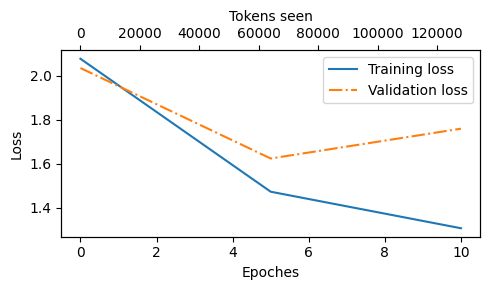

In [38]:
epoch_tensor = torch.linspace(0, num_epoches, len(train_losses))
plot_lossess(epoch_tensor, tokens_seen, train_losses, val_lossess)

In [39]:
# loading a bigger dataset
train_loader, val_loader = prepare_datasets_from_textfile(NAMEGPT_CONFIG, "names_dataset_large.txt")
len(train_loader), len(val_loader)


(18780, 2060)

In [40]:
num_epoches = 2
train_losses, val_lossess, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epoches=num_epoches, eval_freq=1000, eval_iter=5,
    start_context= "de", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 2.761, Val loss 2.793
Ep 1 (Step 001000): Train loss 2.007, Val loss 2.058
Ep 1 (Step 002000): Train loss 2.088, Val loss 1.827
Ep 1 (Step 003000): Train loss 1.866, Val loss 2.044
Ep 1 (Step 004000): Train loss 1.796, Val loss 2.046
Ep 1 (Step 005000): Train loss 1.837, Val loss 1.845
Ep 1 (Step 006000): Train loss 1.852, Val loss 2.025
Ep 1 (Step 007000): Train loss 1.778, Val loss 1.845
Ep 1 (Step 008000): Train loss 1.803, Val loss 1.707
Ep 1 (Step 009000): Train loss 1.900, Val loss 2.020
Ep 1 (Step 010000): Train loss 1.837, Val loss 1.785
Ep 1 (Step 011000): Train loss 1.812, Val loss 1.851
Ep 1 (Step 012000): Train loss 1.872, Val loss 1.947
Ep 1 (Step 013000): Train loss 1.832, Val loss 1.775
Ep 1 (Step 014000): Train loss 1.745, Val loss 1.814
Ep 1 (Step 015000): Train loss 1.891, Val loss 1.793
Ep 1 (Step 016000): Train loss 1.800, Val loss 1.802
Ep 1 (Step 017000): Train loss 1.653, Val loss 1.830
Ep 1 (Step 018000): Train loss 1.695, Val loss

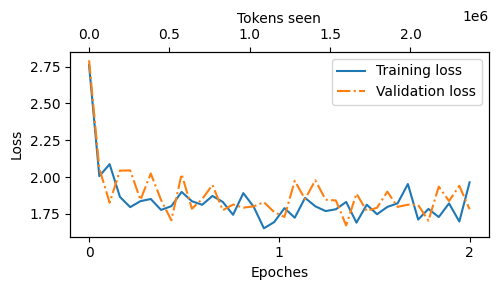

In [41]:
epoch_tensor = torch.linspace(0, num_epoches, len(train_losses))
plot_lossess(epoch_tensor, tokens_seen, train_losses, val_lossess)

In [42]:
def save_model(model):
    torch.save({
        "model_state_dict": model.state_dict(), 
        "optimizer_state_dict": optimizer.state_dict()
    }, f"model-{datetime.now().strftime("%d%m%Y-%H.%M")}" )

In [43]:
save_model(model)

In [28]:
def load_model(model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_name, map_location=device)
    model = GPTModel(NAMEGPT_CONFIG)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return model, optimizer

In [29]:
!ls

first_name.txt			    model-02012026-19.06
Indian-Female-Names.csv		    model-02012026-19.07
Indian-Male-Names.csv		    model-02012026-19.57
Indian_Names.csv		    NameGPT.ipynb
Indian_Names_data_preprocessing.py  names_dataset_large.txt
last_name.txt			    README.md
model-02012026-17.19


In [30]:
model, optimizer = load_model("model-02012026-19.57")

In [39]:
model.to(device)

GPTModel(
  (tok_embedding): Embedding(27, 96)
  (pos_embedding): Embedding(8, 96)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MaskedMultiheadAttention(
        (W_key): Linear(in_features=96, out_features=96, bias=False)
        (W_query): Linear(in_features=96, out_features=96, bias=False)
        (W_value): Linear(in_features=96, out_features=96, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=96, out_features=96, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU()
          (2): Linear(in_features=384, out_features=96, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MaskedMultiheadAttention(
        (W_key): Lin

In [44]:
generate_and_print_sample(model, tokenizer, device, "dee", no_samples=10)

deepanan 
nandaraj 
charanjan 
nandaraj 
oganathan 
varanthan 
xaranjan 
ellianna 
uranandan 
waranjan 


In [37]:
device

device(type='cuda')